<a href="https://colab.research.google.com/github/ss48/opencv/blob/master/Copy_of_Face_Detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from google.colab import files
uploaded = files.upload()
print(uploaded.keys())



Saving man2.png to man2 (1).png
dict_keys(['man2 (1).png'])


In [5]:
!rm -f /content/face_detection_yunet.onnx /content/face_recognition_sface.onnx

!wget -O /content/face_detection_yunet.onnx \
"https://huggingface.co/opencv/opencv_zoo/resolve/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx?download=true"

!wget -O /content/face_recognition_sface.onnx \
"https://huggingface.co/opencv/opencv_zoo/resolve/main/models/face_recognition_sface/face_recognition_sface_2021dec.onnx?download=true"

!ls -lh /content/face_detection_yunet.onnx /content/face_recognition_sface.onnx


--2026-03-15 20:58:34--  https://huggingface.co/opencv/opencv_zoo/resolve/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx?download=true
Resolving huggingface.co (huggingface.co)... 3.171.171.6, 3.171.171.104, 3.171.171.128, ...
Connecting to huggingface.co (huggingface.co)|3.171.171.6|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/6835c1a834109f3463ba2273/d3fbb6028fc86125755b70f69f428ebbf39fbb01cfa5df3e3dbe1563148ae349?response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27face_detection_yunet_2023mar.onnx%3B+filename%3D%22face_detection_yunet_2023mar.onnx%22%3B&Expires=1773611914&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiRXBvY2hUaW1lIjoxNzczNjExOTE0fX0sIlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjgzNWMxYTgzNDEwOWYzNDYzYmEyMjczL2QzZmJiNjAyOGZjODYxMjU3NTViNzBmNjlmNDI4ZWJiZjM5ZmJiMDFjZmE1ZGYzZTNkYmUxNTYzMTQ4YWUzNDlcXD9yZXNwb25zZS1jb250ZW50

In [9]:
!ls -lh /content/face_detection_yunet.onnx /content/face_recognition_sface.onnx


-rw-r--r-- 1 root root 228K Mar 15 20:58 /content/face_detection_yunet.onnx
-rw-r--r-- 1 root root  37M Mar 15 20:58 /content/face_recognition_sface.onnx


Face 0, top-left coordinates: (397, 123), box width: 251, box height: 339, score: 0.95


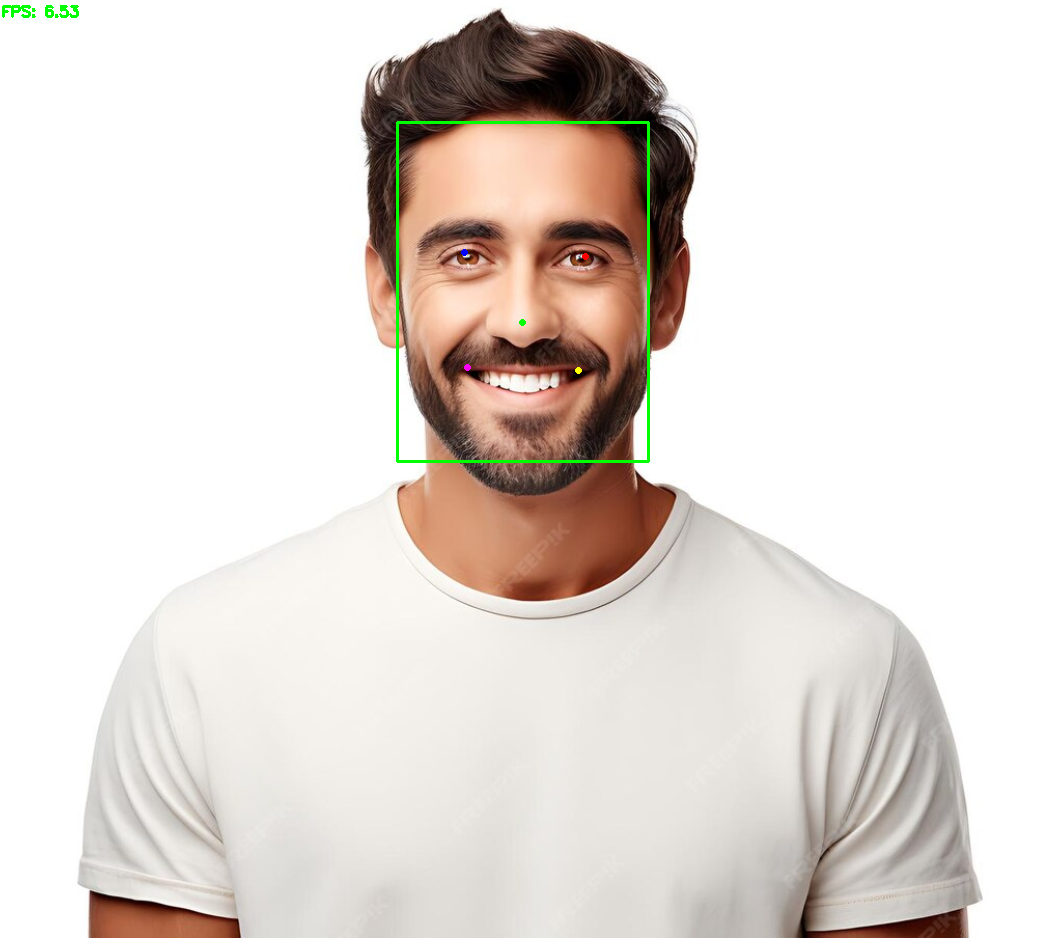

In [21]:
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow

image1 = "/content/man1.png"
face_detection_model = "/content/face_detection_yunet.onnx"

scale = 1.0
score_threshold = 0.9
nms_threshold = 0.3
top_k = 5000
save = False

def visualize(image, faces, fps, thickness=2):
    if faces[1] is not None:
        for idx, face in enumerate(faces[1]):
            print(
                f"Face {idx}, top-left coordinates: ({face[0]:.0f}, {face[1]:.0f}), "
                f"box width: {face[2]:.0f}, box height: {face[3]:.0f}, "
                f"score: {face[-1]:.2f}"
            )

            coords = face[:-1].astype(np.int32)
            cv.rectangle(image, (coords[0], coords[1]),
                         (coords[0] + coords[2], coords[1] + coords[3]),
                         (0, 255, 0), thickness)
            cv.circle(image, (coords[4], coords[5]), 2, (255, 0, 0), thickness)
            cv.circle(image, (coords[6], coords[7]), 2, (0, 0, 255), thickness)
            cv.circle(image, (coords[8], coords[9]), 2, (0, 255, 0), thickness)
            cv.circle(image, (coords[10], coords[11]), 2, (255, 0, 255), thickness)
            cv.circle(image, (coords[12], coords[13]), 2, (0, 255, 255), thickness)

    cv.putText(image, f"FPS: {fps:.2f}", (1, 16),
               cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

img1 = cv.imread(image1)
if img1 is None:
    raise ValueError(f"Could not read image: {image1}")

img1_width = int(img1.shape[1] * scale)
img1_height = int(img1.shape[0] * scale)
img1 = cv.resize(img1, (img1_width, img1_height))

detector = cv.FaceDetectorYN.create(
    face_detection_model,
    "",
    (320, 320),
    score_threshold,
    nms_threshold,
    top_k
)

tm = cv.TickMeter()
tm.start()
detector.setInputSize((img1_width, img1_height))
faces1 = detector.detect(img1)
tm.stop()

if faces1[1] is None:
    raise ValueError(f"Cannot find a face in {image1}")

visualize(img1, faces1, tm.getFPS())

if save:
    cv.imwrite("/content/result.jpg", img1)

cv2_imshow(img1)


/content/face_detection_yunet.onnx exists: True
/content/face_recognition_sface.onnx exists: True
/content/man1.png exists: True
/content/man2.png exists: True
Face 0, top-left coordinates: (397, 123), box width: 251, box height: 339, score: 0.95


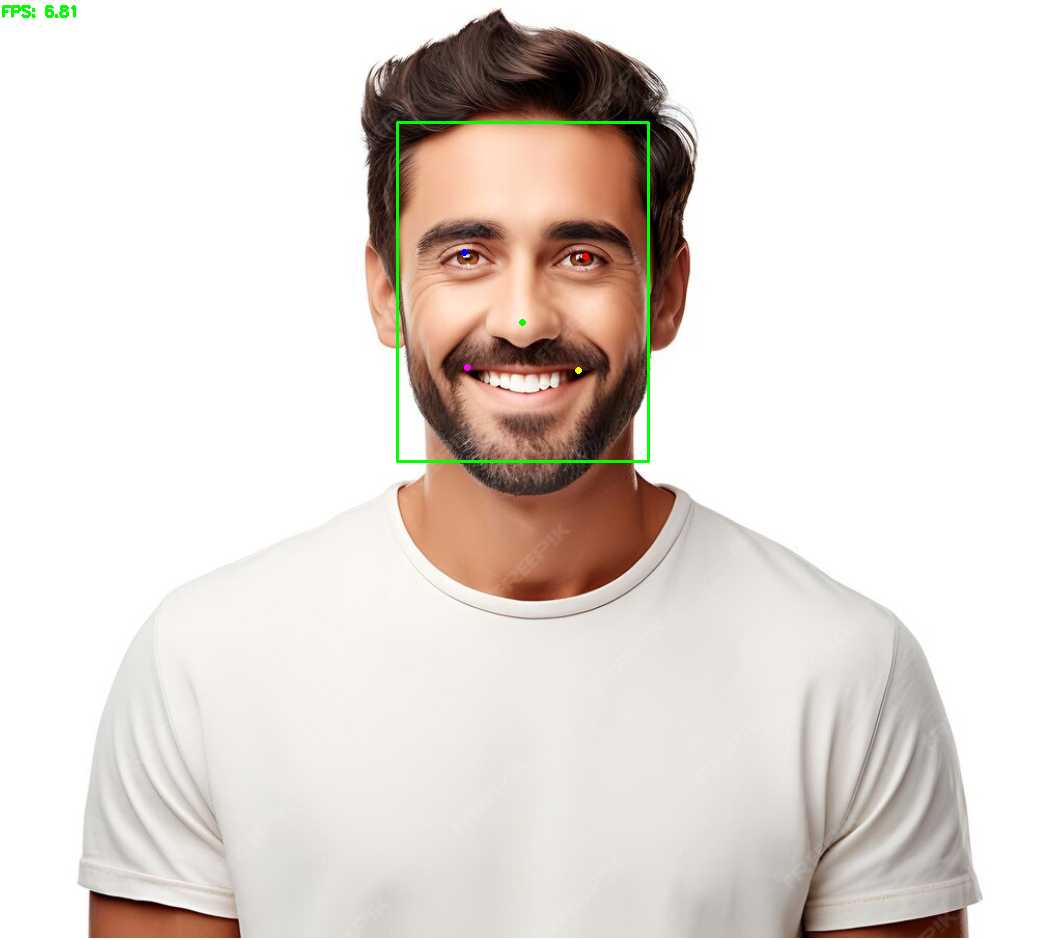

Face 0, top-left coordinates: (605, 116), box width: 385, box height: 601, score: 0.88
Face 1, top-left coordinates: (458, 318), box width: 126, box height: 169, score: 0.79


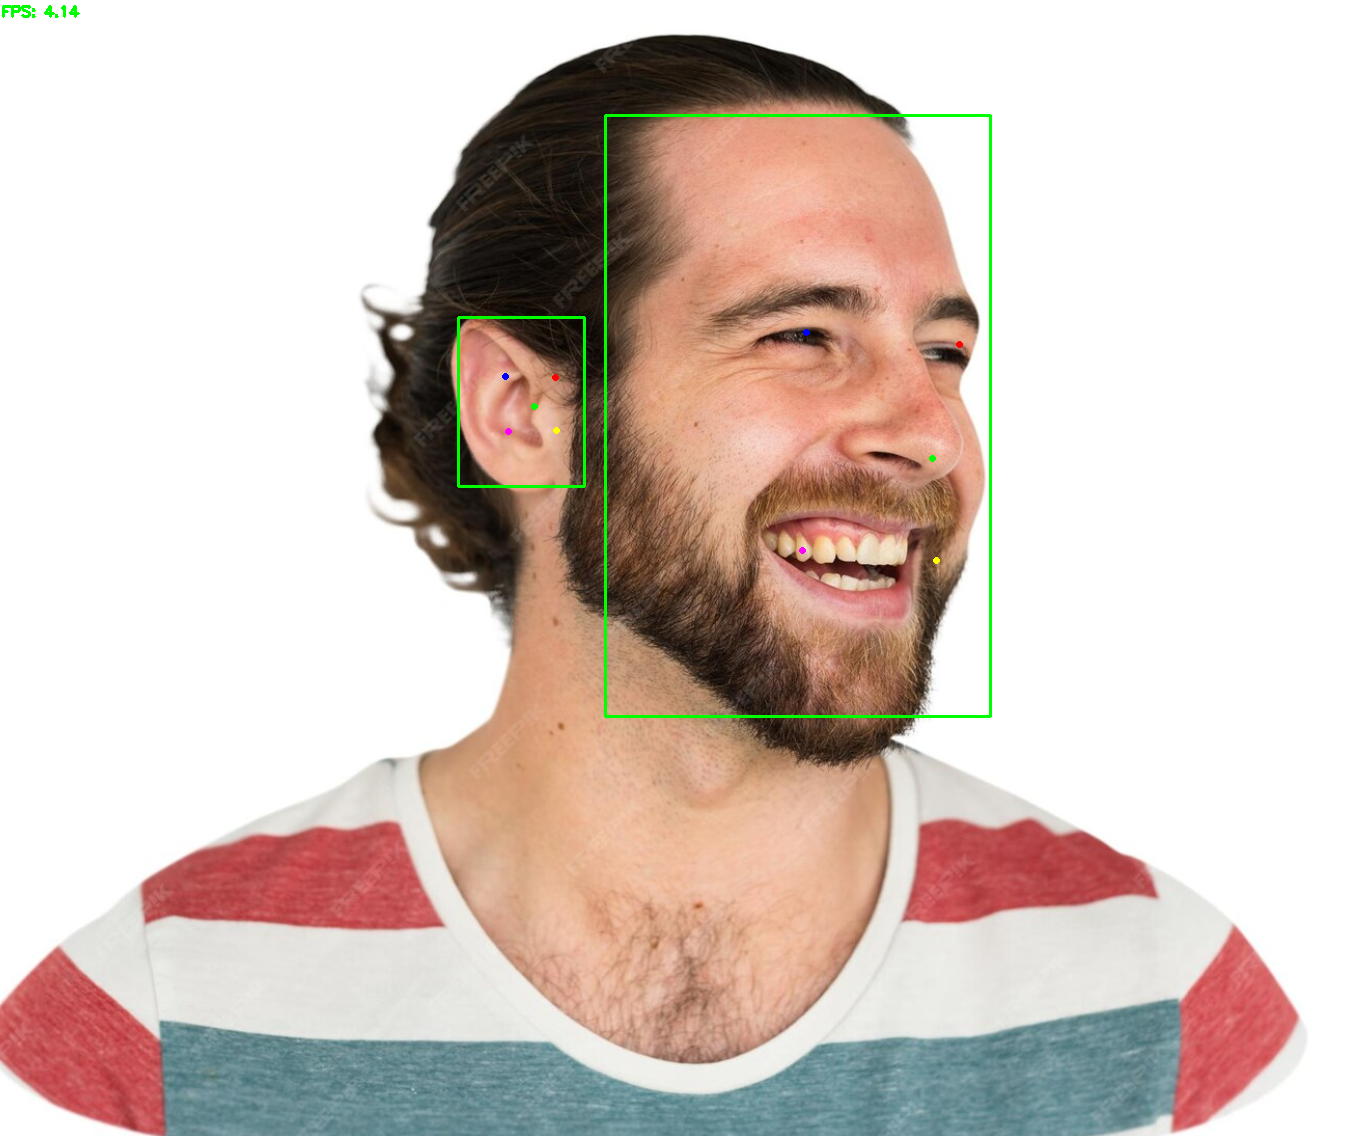

They have different identities. Cosine Similarity: 0.2090, threshold: 0.363
They have different identities. NormL2 Distance: 1.2578, threshold: 1.128


In [22]:
import os
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow

# ----------------------------
# Paths
# ----------------------------
image1 = "/content/man1.png"
image2 = "/content/man2.png"

face_detection_model = "/content/face_detection_yunet.onnx"
face_recognition_model = "/content/face_recognition_sface.onnx"

scale = 1.0
score_threshold = 0.5
nms_threshold = 0.3
top_k = 5000
save = False

# ----------------------------
# Check files exist
# ----------------------------
for p in [face_detection_model, face_recognition_model, image1, image2]:
    print(p, "exists:", os.path.exists(p))

def visualize(image, faces, fps, thickness=2):
    if faces[1] is not None:
        for idx, face in enumerate(faces[1]):
            print(
                f"Face {idx}, top-left coordinates: ({face[0]:.0f}, {face[1]:.0f}), "
                f"box width: {face[2]:.0f}, box height: {face[3]:.0f}, "
                f"score: {face[-1]:.2f}"
            )

            coords = face[:-1].astype(np.int32)
            cv.rectangle(image, (coords[0], coords[1]),
                         (coords[0] + coords[2], coords[1] + coords[3]),
                         (0, 255, 0), thickness)
            cv.circle(image, (coords[4], coords[5]), 2, (255, 0, 0), thickness)
            cv.circle(image, (coords[6], coords[7]), 2, (0, 0, 255), thickness)
            cv.circle(image, (coords[8], coords[9]), 2, (0, 255, 0), thickness)
            cv.circle(image, (coords[10], coords[11]), 2, (255, 0, 255), thickness)
            cv.circle(image, (coords[12], coords[13]), 2, (0, 255, 255), thickness)

    cv.putText(image, f"FPS: {fps:.2f}", (1, 16),
               cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# ----------------------------
# Load detector
# ----------------------------
detector = cv.FaceDetectorYN.create(
    face_detection_model,
    "",
    (640, 640),
    score_threshold,
    nms_threshold,
    top_k
)

tm = cv.TickMeter()

# ----------------------------
# Read first image
# ----------------------------
img1 = cv.imread(image1)
if img1 is None:
    raise ValueError(f"Could not read image: {image1}")

img1_width = int(img1.shape[1] * scale)
img1_height = int(img1.shape[0] * scale)
img1 = cv.resize(img1, (img1_width, img1_height))

tm.start()
detector.setInputSize((img1_width, img1_height))
faces1 = detector.detect(img1)
tm.stop()

if faces1[1] is None:
    raise ValueError(f"Cannot find a face in {image1}")

visualize(img1, faces1, tm.getFPS())

if save:
    cv.imwrite("/content/result1.jpg", img1)

cv2_imshow(img1)

# ----------------------------
# Read second image
# ----------------------------
img2 = cv.imread(image2)
if img2 is None:
    raise ValueError(f"Could not read image: {image2}")

img2_width = int(img2.shape[1] * scale)
img2_height = int(img2.shape[0] * scale)
img2 = cv.resize(img2, (img2_width, img2_height))

tm.reset()
tm.start()
detector.setInputSize((img2_width, img2_height))
faces2 = detector.detect(img2)
tm.stop()

if faces2[1] is None:
    raise ValueError(f"Cannot find a face in {image2}")

visualize(img2, faces2, tm.getFPS())

if save:
    cv.imwrite("/content/result2.jpg", img2)

cv2_imshow(img2)

# ----------------------------
# Face recognition
# ----------------------------
recognizer = cv.FaceRecognizerSF.create(
    face_recognition_model,
    ""
)

face1_align = recognizer.alignCrop(img1, faces1[1][0])
face2_align = recognizer.alignCrop(img2, faces2[1][0])

face1_feature = recognizer.feature(face1_align)
face2_feature = recognizer.feature(face2_align)

cosine_similarity_threshold = 0.363
l2_similarity_threshold = 1.128

cosine_score = recognizer.match(
    face1_feature, face2_feature, cv.FaceRecognizerSF_FR_COSINE
)
l2_score = recognizer.match(
    face1_feature, face2_feature, cv.FaceRecognizerSF_FR_NORM_L2
)

msg = "different identities"
if cosine_score >= cosine_similarity_threshold:
    msg = "the same identity"
print(f"They have {msg}. Cosine Similarity: {cosine_score:.4f}, threshold: {cosine_similarity_threshold}")

msg = "different identities"
if l2_score <= l2_similarity_threshold:
    msg = "the same identity"
print(f"They have {msg}. NormL2 Distance: {l2_score:.4f}, threshold: {l2_similarity_threshold}")
